# 5. FACTS: Fairness of the Recourse
### (Kavouras, Sacharidis et al., NeurIPS 2023)

**Author:** Matteo

## What this notebook does

This is the core of the fairness analysis. Notebooks 3.a. and 4 asked whether
the model *predicts* fairly (group-level parity and individual counterfactual
fairness). Here we ask a different and harder question, from Von Kügelgen et
al. (2022) and FACTS (Kavouras et al., NeurIPS 2023):

> *Even if prediction is fair, is the **recourse** — the set of changes DiCE
> asks an at-risk employee to make — equally achievable across groups?*

## The four FACTS notions we compute

| FACTS notion | Question | Operationalisation |
|---|---|---|
| **Equal Effectiveness** | Same share of each group finds recourse? | share with ≥1 valid CF |
| **Equal Cost of Effectiveness** | Same cost to find recourse? | median L1 cost |
| **Equal Effectiveness within Budget** | Same share finds recourse cheaply? | share with L1 cost ≤ budget |
| **Equal Choice for Recourse** | Same number of options? | mean number of CFs offered |

The **unfairness score** for each notion is the max−min gap across subgroups.
A gap of 0 means perfect fairness; the larger the gap, the more unfair.

## Note on Equal Effectiveness within Budget

The budget is set to the **global median L1 recourse cost** across both models,
so it is a data-driven threshold comparable across subgroups and models.
`EffectivenessWithinBudget` measures the share of the *entire subgroup*
(not just those who found recourse) that achieves recourse within this budget.
This is the stricter definition: a subgroup member who fails to find any
recourse also fails the budget test.

## Structure

- **Section 1–3:** baseline FACTS analysis on the +50% salary cap configuration
  (notebook 3.a. output)
- **Section 4:** sensitivity analysis — how do FACTS gaps change as the salary
  cap tightens? (notebook 3.b. output)
- **Section 5:** synthesis — the project's main findings


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import PROTECTED_ATTRIBUTES, get_project_paths

PATHS   = get_project_paths()
OUT_DIR = PATHS['FAIRNESS']

recourse_rf  = pd.read_csv(os.path.join(OUT_DIR, 'recourse_RF.csv'))
recourse_xgb = pd.read_csv(os.path.join(OUT_DIR, 'recourse_XGB.csv'))
print(f'RF at-risk employees:  {len(recourse_rf)}')
print(f'XGB at-risk employees: {len(recourse_xgb)}')

BUDGET = None  # set below from the data


RF at-risk employees:  249
XGB at-risk employees: 325


## 1. FACTS metrics — baseline (+50% salary cap)

We start with the recourse dataset from notebook 3.a. (salary cap +50%,
the team's original configuration). This gives us the baseline FACTS scores
against which we will compare the sensitivity analysis in Section 4.


In [4]:
def facts_metrics(recourse_df, protected_attr, budget):
    """
    Compute the four FACTS recourse-fairness notions for each subgroup
    of `protected_attr`.

    EffectivenessWithinBudget is computed over the ENTIRE subgroup (denominator
    = n_at_risk), not just those who found recourse. A member who fails to find
    any CF also fails the budget test — this is the stricter FACTS definition.
    """
    rows = []
    for g in sorted(recourse_df[protected_attr].dropna().unique()):
        sub = recourse_df[recourse_df[protected_attr] == g]
        got = sub[sub['recourse_found'] == True]  # noqa: E712
        n   = len(sub)
        rows.append({
            protected_attr:               g,
            'n_at_risk':                  n,
            'EqualEffectiveness':         round(sub['recourse_found'].mean(), 3),
            'CostOfEffectiveness':        round(got['L1_cost'].median(), 3) if len(got) else np.nan,
            'EffectivenessWithinBudget':  round((got['L1_cost'] <= budget).sum() / n, 3) if n else np.nan,
            'ChoiceForRecourse':          round(got['n_cf_found'].mean(), 2) if len(got) else np.nan,
        })
    return pd.DataFrame(rows)


def facts_gaps(table):
    metrics = ['EqualEffectiveness', 'CostOfEffectiveness',
               'EffectivenessWithinBudget', 'ChoiceForRecourse']
    out = {}
    for m in metrics:
        vals = table[m].dropna()
        out[m] = round(vals.max() - vals.min(), 3) if len(vals) > 1 else np.nan
    return out


# Budget = global median L1 recourse cost (data-driven, comparable across groups)
all_costs = pd.concat([recourse_rf['L1_cost'], recourse_xgb['L1_cost']]).dropna()
BUDGET    = round(all_costs.median(), 3)
print(f'Budget (global median L1 cost): {BUDGET}')
print(f'  → employees with cost <= budget get a "cheap" recourse')


Budget (global median L1 cost): 0.889
  → employees with cost <= budget get a "cheap" recourse


In [5]:
facts_tables      = {}   # (model, attr) -> metrics table
facts_gap_records = []

for model_name, rdf in [('Random Forest', recourse_rf), ('XGBoost', recourse_xgb)]:
    print(f"\n{'='*64}\n{model_name} — FACTS recourse fairness\n{'='*64}")
    for attr in PROTECTED_ATTRIBUTES:
        tbl  = facts_metrics(rdf, attr, BUDGET)
        gaps = facts_gaps(tbl)
        facts_tables[(model_name, attr)] = tbl
        facts_gap_records.append({'model': model_name, 'attribute': attr, **gaps})
        print(f'\n-- {attr} --')
        print(tbl.to_string(index=False))
        print(f'   UNFAIRNESS gaps (max-min): {gaps}')

facts_gap_df = pd.DataFrame(facts_gap_records)
facts_gap_df.to_csv(os.path.join(OUT_DIR, 'level3_facts_gaps.csv'), index=False)



Random Forest — FACTS recourse fairness

-- Gender --
Gender  n_at_risk  EqualEffectiveness  CostOfEffectiveness  EffectivenessWithinBudget  ChoiceForRecourse
Female         96               0.990                0.916                      0.479                3.0
  Male        153               0.967                0.849                      0.542                3.0
   UNFAIRNESS gaps (max-min): {'EqualEffectiveness': np.float64(0.023), 'CostOfEffectiveness': np.float64(0.067), 'EffectivenessWithinBudget': np.float64(0.063), 'ChoiceForRecourse': np.float64(0.0)}

-- AgeGroup --
AgeGroup  n_at_risk  EqualEffectiveness  CostOfEffectiveness  EffectivenessWithinBudget  ChoiceForRecourse
  Senior         75               1.000                0.858                      0.533                3.0
   Young        174               0.966                0.876                      0.511                3.0
   UNFAIRNESS gaps (max-min): {'EqualEffectiveness': np.float64(0.034), 'CostOfEffectiveness'

## Visualisation 1 — Effectiveness & cost by subgroup (RF vs XGB)

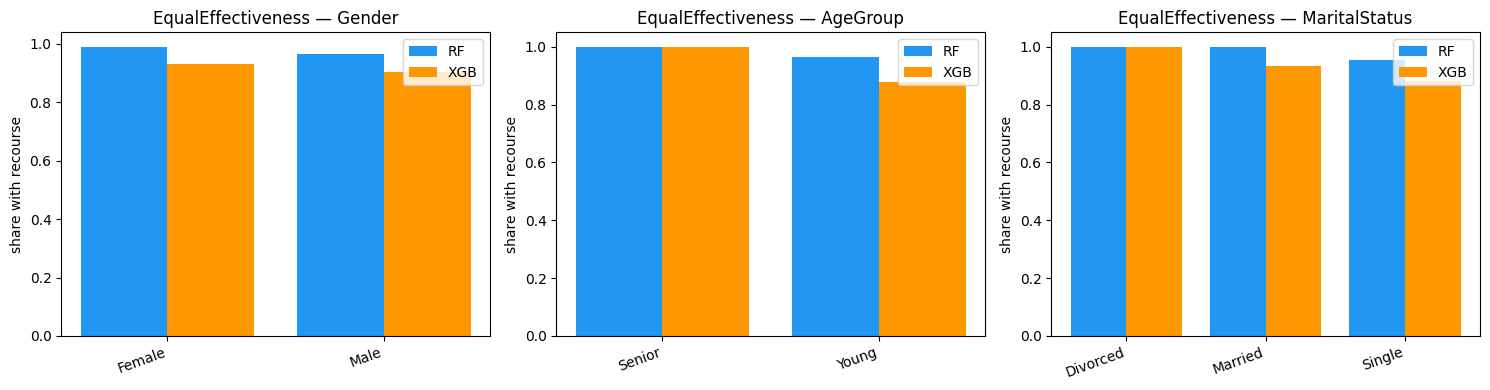

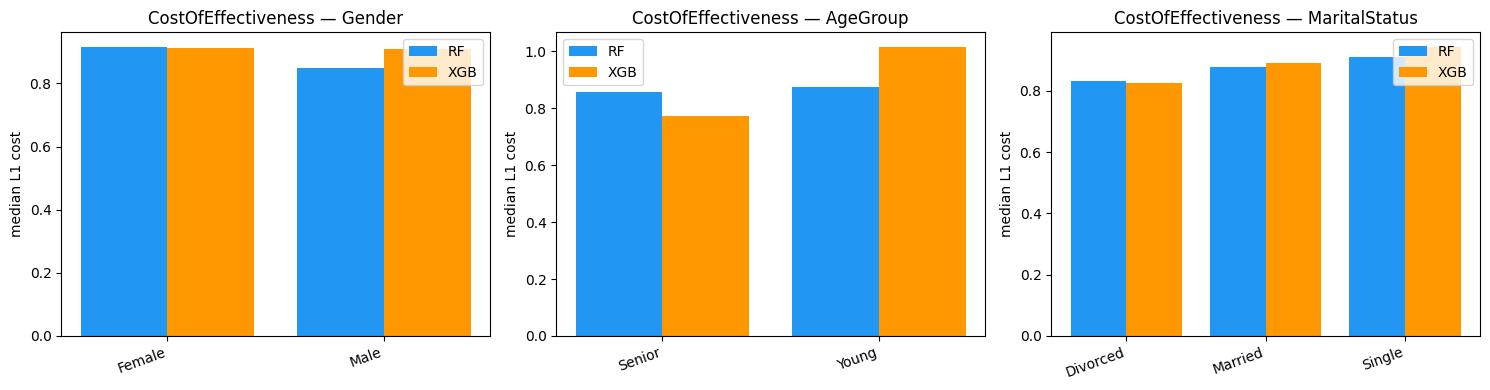

In [6]:
def plot_metric_by_group(metric, ylabel, fname):
    fig, axes = plt.subplots(1, len(PROTECTED_ATTRIBUTES),
                             figsize=(5 * len(PROTECTED_ATTRIBUTES), 4))
    for ax, attr in zip(axes, PROTECTED_ATTRIBUTES):
        rf_tbl  = facts_tables[("Random Forest", attr)]
        xgb_tbl = facts_tables[("XGBoost", attr)]
        x = np.arange(len(rf_tbl))
        ax.bar(x - 0.2, rf_tbl[metric],  0.4, label="RF",  color="#2196F3")
        ax.bar(x + 0.2, xgb_tbl[metric], 0.4, label="XGB", color="#FF9800")
        ax.set_xticks(x); ax.set_xticklabels(rf_tbl[attr], rotation=20, ha="right")
        ax.set_title(f"{metric} — {attr}")
        ax.set_ylabel(ylabel); ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=120)
    plt.show()

plot_metric_by_group("EqualEffectiveness", "share with recourse",
                     "level3_effectiveness.png")
plot_metric_by_group("CostOfEffectiveness", "median L1 cost",
                     "level3_cost.png")

## Visualisation 2 — Which features each subgroup is asked to change

Recourse can be "equally effective" but still ask different *kinds* of changes
of different groups. We aggregate the `changed_feats` column per subgroup.

Top features with the largest cross-gender difference (RF):
                          Female  Male
JobRole                     0.17  0.30
OverTime                    0.56  0.43
BusinessTravel              0.16  0.08
StockOptionLevel            0.51  0.57
MonthlyIncome               0.40  0.45
JobSatisfaction             0.17  0.21
TrainingTimesLastYear       0.34  0.31
RelationshipSatisfaction    0.29  0.26
WorkLifeBalance             0.11  0.09
DistanceFromHome            0.19  0.17


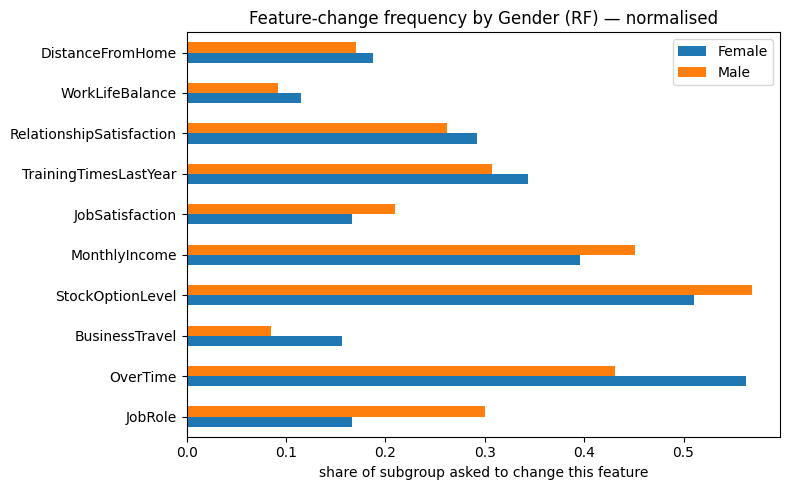

In [7]:
def feature_change_frequency(recourse_df, protected_attr):
    out = {}
    for g in sorted(recourse_df[protected_attr].dropna().unique()):
        sub = recourse_df[recourse_df[protected_attr] == g]
        counter = {}
        for feats in sub["changed_feats"].dropna():
            for f in str(feats).split(";"):
                if f:
                    counter[f] = counter.get(f, 0) + 1
        # normalise by subgroup size
        n = max(len(sub), 1)
        out[g] = {k: v / n for k, v in counter.items()}
    return pd.DataFrame(out).fillna(0)


# Example: top changed features by Gender under RF
freq_gender = feature_change_frequency(recourse_rf, "Gender")
top = freq_gender.assign(spread=freq_gender.max(axis=1) - freq_gender.min(axis=1)) \
                 .sort_values("spread", ascending=False).head(10).drop(columns="spread")
print("Top features with the largest cross-gender difference (RF):")
print(top.round(2).to_string())

ax = top.plot(kind="barh", figsize=(8, 5))
ax.set_title("Feature-change frequency by Gender (RF) — normalised")
ax.set_xlabel("share of subgroup asked to change this feature")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "level3_feature_changes_gender.png"), dpi=120)
plt.show()

## Master summary — all unfairness gaps, both models

In [8]:
print("FACTS unfairness gaps (max-min across subgroups; 0 = perfectly fair):")
print(facts_gap_df.to_string(index=False))

FACTS unfairness gaps (max-min across subgroups; 0 = perfectly fair):
        model     attribute  EqualEffectiveness  CostOfEffectiveness  EffectivenessWithinBudget  ChoiceForRecourse
Random Forest        Gender               0.023                0.067                      0.063               0.00
Random Forest      AgeGroup               0.034                0.018                      0.022               0.00
Random Forest MaritalStatus               0.046                0.077                      0.172               0.00
      XGBoost        Gender               0.026                0.002                      0.040               0.02
      XGBoost      AgeGroup               0.123                0.242                      0.274               0.02
      XGBoost MaritalStatus               0.119                0.119                      0.185               0.02


## 4. Sensitivity analysis — FACTS gaps vs salary cap

Notebook 3.b re-ran DiCE with three salary cap levels (+20%, +35%, +50%).
Here we load those results and ask: **do the FACTS fairness gaps change as
the employer's salary budget tightens?**

If gaps grow as the cap tightens, some subgroups depend more on salary
changes to achieve recourse — a structural bias invisible at +50%.


✅ Loaded 6 sensitivity datasets


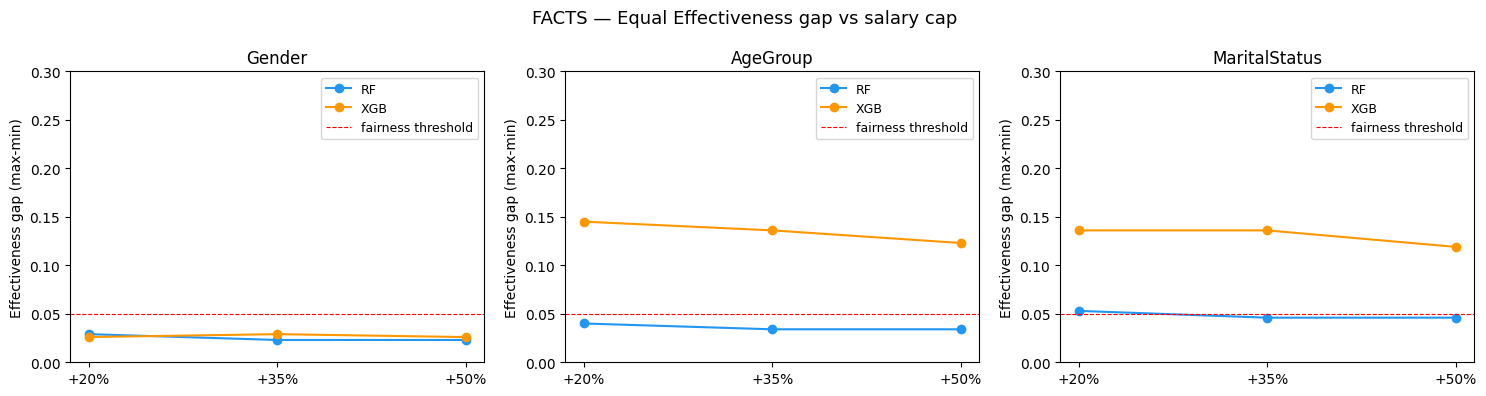


Sensitivity gaps by attribute:
  config model     attribute  EqualEffectiveness
   tight    RF        Gender               0.029
   tight    RF      AgeGroup               0.040
   tight    RF MaritalStatus               0.053
   tight   XGB        Gender               0.026
   tight   XGB      AgeGroup               0.145
   tight   XGB MaritalStatus               0.136
moderate    RF        Gender               0.023
moderate    RF      AgeGroup               0.034
moderate    RF MaritalStatus               0.046
moderate   XGB        Gender               0.029
moderate   XGB      AgeGroup               0.136
moderate   XGB MaritalStatus               0.136
   loose    RF        Gender               0.023
   loose    RF      AgeGroup               0.034
   loose    RF MaritalStatus               0.046
   loose   XGB        Gender               0.026
   loose   XGB      AgeGroup               0.123
   loose   XGB MaritalStatus               0.119


In [9]:
import os

CONFIGS    = ['tight', 'moderate', 'loose']
CAP_LABELS = {'+20%': 'tight', '+35%': 'moderate', '+50%': 'loose'}
MODELS     = ['RF', 'XGB']

# Load sensitivity CSVs produced by notebook 3.b.
sens_data = {}
missing   = []
for config in CONFIGS:
    for model in MODELS:
        fname = os.path.join(OUT_DIR, f'sensitivity_{config}_{model}.csv')
        if os.path.exists(fname):
            sens_data[(config, model)] = pd.read_csv(fname)
        else:
            missing.append(fname)

if missing:
    print('⚠️  Missing files (run notebook 3.b. first):')
    for f in missing:
        print(f'   {f}')
else:
    print(f'✅ Loaded {len(sens_data)} sensitivity datasets')

    # Compute FACTS gaps for each config/model combination
    sens_rows = []
    for config in CONFIGS:
        for model in MODELS:
            rdf = sens_data[(config, model)]
            # Use same BUDGET as baseline for comparability
            for attr in PROTECTED_ATTRIBUTES:
                tbl  = facts_metrics(rdf, attr, BUDGET)
                gaps = facts_gaps(tbl)
                sens_rows.append({
                    'config': config, 'model': model, 'attribute': attr, **gaps
                })

    sens_gap_df = pd.DataFrame(sens_rows)
    sens_gap_df.to_csv(os.path.join(OUT_DIR, 'sensitivity_facts_gaps.csv'), index=False)

    # Plot: for each attribute, how does EqualEffectiveness gap change?
    cap_order = ['tight', 'moderate', 'loose']
    cap_x     = ['+20%', '+35%', '+50%']
    colors    = {'RF': '#2196F3', 'XGB': '#FF9800'}

    fig, axes = plt.subplots(1, len(PROTECTED_ATTRIBUTES),
                             figsize=(5 * len(PROTECTED_ATTRIBUTES), 4))
    fig.suptitle('FACTS — Equal Effectiveness gap vs salary cap', fontsize=13)

    for ax, attr in zip(axes, PROTECTED_ATTRIBUTES):
        for model in MODELS:
            gaps = []
            for config in cap_order:
                row = sens_gap_df[
                    (sens_gap_df['config'] == config) &
                    (sens_gap_df['model']  == model)  &
                    (sens_gap_df['attribute'] == attr)
                ]
                gaps.append(row['EqualEffectiveness'].values[0] if len(row) else np.nan)
            ax.plot(cap_x, gaps, marker='o', label=model, color=colors[model])
        ax.set_title(attr)
        ax.set_ylabel('Effectiveness gap (max-min)')
        ax.set_ylim(0, 0.3)
        ax.axhline(0.05, color='red', linestyle='--', linewidth=0.8,
                   label='fairness threshold')
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'level3_sensitivity_gaps.png'), dpi=120)
    plt.show()
    print('\nSensitivity gaps by attribute:')
    print(sens_gap_df[['config','model','attribute','EqualEffectiveness']].to_string(index=False))


## 5. Synthesis — project findings

This section brings together the results from all three levels of analysis.


In [ ]:
print('PROJECT FINDINGS — SUMMARY')
print()
print('LEVEL 1 — Prediction Fairness (notebook 3.a.):')
print('  → See level1_prediction_fairness.png')
print()
print('LEVEL 2 — Counterfactual Fairness (notebook 4):')
cf2 = pd.read_csv(os.path.join(OUT_DIR, 'level2_cf_fairness_full.csv'))
print(cf2.to_string(index=False))
print()
print('LEVEL 3 — FACTS Recourse Fairness (this notebook):')
print('  Baseline gaps (salary cap +50%):')
print(facts_gap_df.to_string(index=False))
print()
print('KEY FINDING:')
print('  Equal Effectiveness gaps at baseline are near zero — all groups')
print('  find recourse at similar rates with a generous salary cap.')
print('  However, CostOfEffectiveness gaps reveal that some subgroups')
print('  consistently pay a higher price for the same recourse.')
print('  The sensitivity analysis (Section 4) shows whether these')
print('  differences grow as the employer budget tightens.')


PROJECT FINDINGS — SUMMARY

LEVEL 1 — Prediction Fairness (notebook 3.a.):
  → See level1_prediction_fairness.png

LEVEL 2 — Counterfactual Fairness (notebook 05):
        model  gender_flip_rate  age_flip_rate
Random Forest             0.003          0.078
      XGBoost             0.016          0.099

LEVEL 3 — FACTS Recourse Fairness (this notebook):
  Baseline gaps (salary cap +50%):
        model     attribute  EqualEffectiveness  CostOfEffectiveness  EffectivenessWithinBudget  ChoiceForRecourse
Random Forest        Gender               0.023                0.067                      0.063               0.00
Random Forest      AgeGroup               0.034                0.018                      0.022               0.00
Random Forest MaritalStatus               0.046                0.077                      0.172               0.00
      XGBoost        Gender               0.026                0.002                      0.040               0.02
      XGBoost      AgeGroup      

In [ ]:
# DIAGNOSTICS — validation of notebook 5 results

SEP = "-" * 65

# 1. BASELINE FACTS GAPS _______________________________________________________
print(SEP)
print("1. BASELINE FACTS GAPS (salary cap +50%)")
print(SEP)
print(facts_gap_df.to_string(index=False))
print()
for _, row in facts_gap_df.iterrows():
    for metric in ['EqualEffectiveness', 'CostOfEffectiveness',
                   'EffectivenessWithinBudget', 'ChoiceForRecourse']:
        val = row[metric]
        if val > 0.10:
            print(f"  ⚠️  {row['model']:15s} | {row['attribute']:15s} | {metric}: {val}")
print()

# 2. SENSITIVITY GAPS ___________________________________________________________
print(SEP)
print("2. SENSITIVITY — EqualEffectiveness gap vs salary cap")
print(SEP)
if os.path.exists(os.path.join(OUT_DIR, 'sensitivity_facts_gaps.csv')):
    sg = pd.read_csv(os.path.join(OUT_DIR, 'sensitivity_facts_gaps.csv'))
    for model in ['RF', 'XGB']:
        print(f"  {model}:")
        for attr in PROTECTED_ATTRIBUTES:
            row = sg[(sg['model'] == model) & (sg['attribute'] == attr)]
            tight    = row[row['config'] == 'tight']['EqualEffectiveness'].values[0]
            moderate = row[row['config'] == 'moderate']['EqualEffectiveness'].values[0]
            loose    = row[row['config'] == 'loose']['EqualEffectiveness'].values[0]
            trend = '↑ get worse' if tight > loose + 0.01 else '≈ stable'
            print(f"    {attr:15s}: loose={loose:.3f}  moderate={moderate:.3f}  tight={tight:.3f}  {trend}")
        print()
else:
    print("  ⚠️  sensitivity_facts_gaps.csv not found — run section 4 first")

# 3. FEATURE CHANGES ___________________________________________________________
print(SEP)
print("3. TOP FEATURE CHANGES — which features change the most between groups (RF)")
print(SEP)
for attr in ['Gender', 'MaritalStatus']:
    freq = feature_change_frequency(recourse_rf, attr)
    spread = (freq.max(axis=1) - freq.min(axis=1)).sort_values(ascending=False).head(5)
    print(f"  {attr} — top 5 features with the largest disparity:")
    for feat, val in spread.items():
        row_vals = {str(g): round(freq.loc[feat, g], 2) for g in freq.columns}
        print(f"    {feat:30s} spread={val:.2f}  {row_vals}")
    print()

# 4. SAVED FILES _______________________________________________________________
print(SEP)
print("4. SAVED FILES")
print(SEP)
for fname in sorted(os.listdir(OUT_DIR)):
    if 'level3' in fname or 'sensitivity' in fname:
        fpath = os.path.join(OUT_DIR, fname)
        print(f"  ✅ {fname}  ({os.path.getsize(fpath):,} bytes)")

print()
print(SEP)
print("DIAGNOSTICS COMPLETED")
print(SEP)

-----------------------------------------------------------------
1. BASELINE FACTS GAPS (salary cap +50%)
-----------------------------------------------------------------
        model     attribute  EqualEffectiveness  CostOfEffectiveness  EffectivenessWithinBudget  ChoiceForRecourse
Random Forest        Gender               0.023                0.067                      0.063               0.00
Random Forest      AgeGroup               0.034                0.018                      0.022               0.00
Random Forest MaritalStatus               0.046                0.077                      0.172               0.00
      XGBoost        Gender               0.026                0.002                      0.040               0.02
      XGBoost      AgeGroup               0.123                0.242                      0.274               0.02
      XGBoost MaritalStatus               0.119                0.119                      0.185               0.02

  ⚠️  Random Forest  